In [3]:
import torch
from torch.distributions import MultivariateNormal, Categorical, MixtureSameFamily
import zuko
import matplotlib.pyplot as plt


In [2]:
# import sys
# !{sys.executable} -m pip install zuko


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# we start with a 4 d problem, get 2, 2d gaussians,
# Use normalizing flows from U[0,1] distr to the gaussian, these are the quantiles
d = 4
N = 10000
mu = torch.zeros(d)

# Covariance matrix (identity) #correlated
Sigma = torch.tensor([
    [1.0, 0.8, 0.2, 0.0],
    [0.8, 1.0, 0.3, 0.15],
    [0.2, 0.3, 1.0, 0.4],
    [0.0, 0.15, 0.4, 1.0]
])

sqrtSigma   = torch.linalg.cholesky(Sigma)
chi2        = torch.distributions.Chi2(df=d)
chi_samples = torch.sqrt(chi2.sample((N,)))

Z           = torch.randn(N, d)
U_samples   = Z / torch.norm(Z, dim=1, keepdim=True)
res         = chi_samples*(sqrtSigma @ U_samples.T)

In [5]:
def Transport(Sigma,res,indx):
    S       = torch.linalg.cholesky(Sigma[indx,indx])
    dist    = torch.distributions.Normal(loc=0, scale=1)
    Transf  = S.T @ res[indx,:]
    print(Transf[1,:])
    blocks  = []
    for i in range(indx.stop - indx.start):
        print(i)
        blocks.append(dist.cdf(Transf[i,:]).unsqueeze(0))
    Z = torch.cat(blocks, dim=0)
    return Z

Z_1 = Transport(Sigma, res, slice(0, 2))
Z_2 = Transport(Sigma, res, slice(2, 4))


tensor([-0.3915, -0.2239,  0.2183,  ...,  0.1491,  0.3533, -0.7098])
0
1
tensor([-1.2041, -1.6271,  0.8223,  ...,  0.4455,  0.5752, -0.8076])
0
1


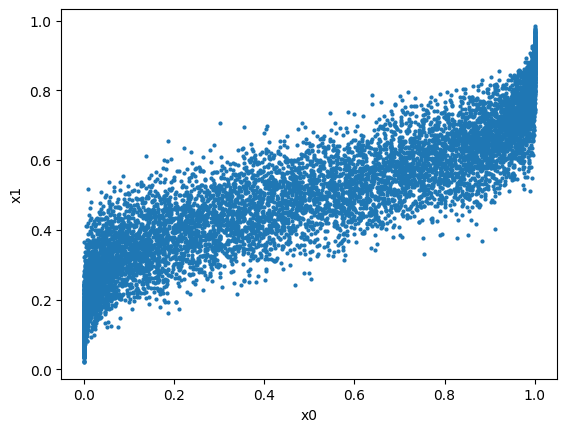

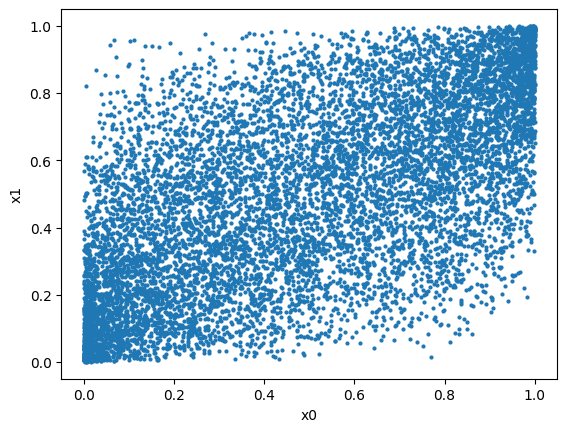

In [6]:
# Distribution object
# dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=Sigma)
def plotMarg(Z):
    X_np = Z.detach().cpu().numpy()
    plt.figure()
    plt.scatter(X_np[0,:], X_np[1,:], s=d)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.show()
plotMarg(Z_1)
plotMarg(Z_2)   
    

In [7]:
### custom 4d distribution, mixture of 2 guassians with different correlation structure -> multimodal and one can tune the connection

weights = torch.tensor([0.4, 0.6])
mix = Categorical(probs=weights)

# Means (2 components × 4 dimensions)
means = torch.tensor([
    [0., 0., 0., 0.],
    [1., 1., 1., 1.]
])

Sigma1 = Sigma = torch.tensor([
    [1.0, 0.8, 0.2, 0.0],
    [0.8, 1.0, 0.3, 0.15],
    [0.2, 0.3, 1.0, 0.4],
    [0.0, 0.15, 0.4, 1.0]
])

Sigma2 = Sigma = torch.tensor([
    [1.0, 0.0, 0.2, 0.3],
    [0.0, 1.0, 0.1, 0.25],
    [0.2, 0.1, 1.0, 0.0],
    [0.3, 0.25, 0.0, 1.0]
])

# Covariances (2 × 4 × 4)
covs = torch.stack([
    Sigma1,
    Sigma2
])
components = MultivariateNormal(loc=means, covariance_matrix=covs)
mixture = MixtureSameFamily(mix, components)


In [ ]:
samp_mix = mixture.sample((10000,))
plotMarg(samp_mix[0:2,:])  